# Baseline B — full record

The complete log of the standard-RAG (B) experiments: every variant, the retrieval bottleneck, the top-k / top-n interaction, and the observations. `../02_comparison` keeps only the headline best; this is the detailed record for the report.

Loads the milestone ladder from `outputs/baselines/` (A → B5). The systematic top-k × top-n sweep on the full test set lives in `outputs/final_test/`; the bottleneck analysis below uses it.

In [1]:
import json, os, re, glob, string
import matplotlib.pyplot as plt

OUT = '../../outputs'
BASE = '/work/cvcs2026/encyclopedic'

DESC = {
    'results_A.json':  ('A: no-RAG', 'VLM only (image + question)'),
    'results_B1.json': ('B1: top1 + first3', 'top-1 article, first 3 sections, no rerank'),
    'results_B2.json': ('B2: top1 + allsec', 'top-1 article, all sections, no rerank'),
    'results_B3.json': ('B3: top5 + CLIP', 'top-5 + CLIP rerank (hurts)'),
    'results_B4.json': ('B4: top5 + cross3', 'top-5 + cross-encoder (top-3)'),
    'results_B5.json': ('B5: top20 + cross20', 'top-20 + cross-encoder (top-20), full KB — best'),
}

rows = []
for f in sorted(glob.glob(OUT + '/baselines/results_*.json')):
    name = os.path.basename(f)
    r = json.load(open(f))
    label, desc = DESC.get(name, (name.replace('results_', '').replace('.json', ''), ''))
    rows.append((label, desc, r['accuracy_overall'], r['accuracy_by_type']))
rows.sort(key=lambda x: x[2], reverse=True)
print('%-24s %-8s %s' % ('variant', 'overall', 'what it tests'))
for label, desc, ov, _ in rows:
    print('%-24s %.3f    %s' % (label, ov, desc))

variant                  overall  what it tests
B5: top20 + cross20      0.403    top-20 + cross-encoder (top-20), full KB — best
B4: top5 + cross3        0.360    top-5 + cross-encoder (top-3)
B2: top1 + allsec        0.295    top-1 article, all sections, no rerank
B1: top1 + first3        0.278    top-1 article, first 3 sections, no rerank
A: no-RAG                0.245    VLM only (image + question)
B3: top5 + CLIP          0.243    top-5 + CLIP rerank (hurts)


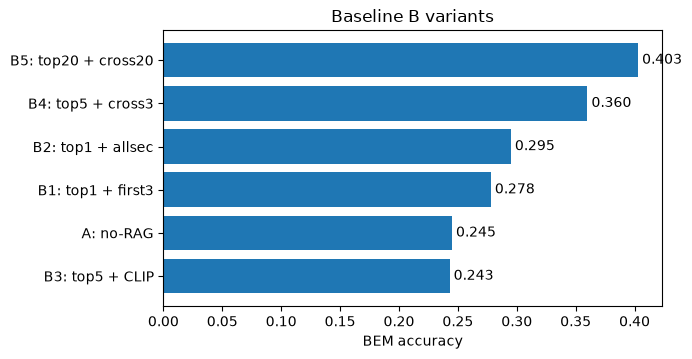

In [2]:
labels = [r[0] for r in rows][::-1]
vals = [r[2] for r in rows][::-1]
plt.figure(figsize=(7, 0.45 * len(labels) + 1))
plt.barh(labels, vals)
for i, v in enumerate(vals):
    plt.text(v, i, ' %.3f' % v, va='center')
plt.xlabel('BEM accuracy'); plt.title('Baseline B variants'); plt.tight_layout(); plt.show()

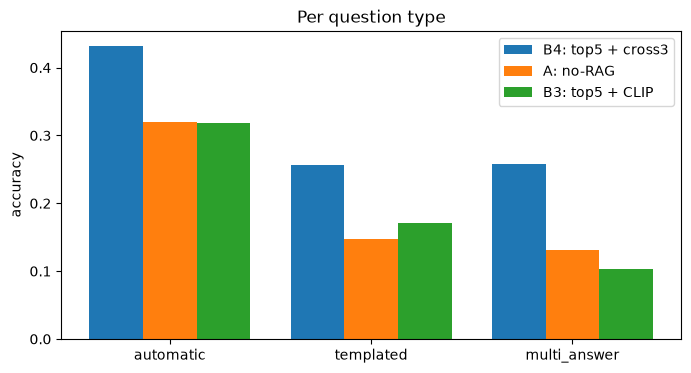

In [3]:
types = ['automatic', 'templated', 'multi_answer']
focus = ['A: no-RAG', 'B3: top5 + CLIP', 'B4: top5 + cross3', 'B5: top50 + cross20']
sel = [(l, byt) for l, _, _, byt in rows if l in focus]
x = range(len(types)); w = 0.8 / max(len(sel), 1)
plt.figure(figsize=(8, 4))
for i, (l, byt) in enumerate(sel):
    off = (i - (len(sel) - 1) / 2) * w
    plt.bar([j + off for j in x], [byt.get(t, 0) for t in types], w, label=l)
plt.xticks(list(x), types); plt.ylabel('accuracy'); plt.legend(); plt.title('Per question type'); plt.show()

## Comparison by question type

Two views of the same signal. The **heatmap** compares every variant across question types at a glance (no legend, so it scales to many variants). The **lift-over-A** chart isolates what each RAG variant *adds* per type — the legend is pushed outside the plot so it never covers the bars.

Takeaway: RAG lifts `automatic` strongly, but `templated` and `multi_answer` stay hard for every variant — the gap that motivates system C.

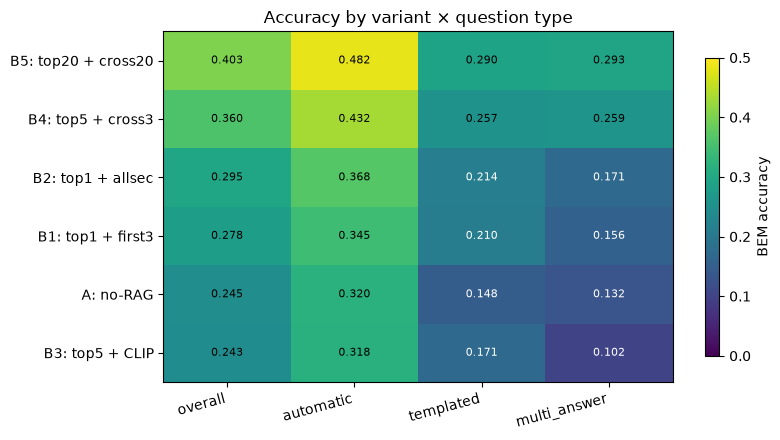

In [4]:
# Heatmap: every variant × question type (+ overall). No legend — colour + annotations,
# so it stays readable no matter how many variants we compare.
import numpy as np
types = ['automatic', 'templated', 'multi_answer']
cols = ['overall'] + types
order = sorted(rows, key=lambda r: r[2], reverse=True)
labels = [r[0] for r in order]
arr = np.array([[ov] + [byt.get(t, 0) for t in types] for _, _, ov, byt in order])

fig, ax = plt.subplots(figsize=(1.3 * len(cols) + 3, 0.5 * len(labels) + 1.5))
im = ax.imshow(arr, cmap='viridis', aspect='auto', vmin=0, vmax=max(0.5, arr.max()))
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=15, ha='right')
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
thr = 0.5 * arr.max()
for i in range(len(labels)):
    for j in range(len(cols)):
        ax.text(j, i, '%.3f' % arr[i, j], ha='center', va='center',
                color='white' if arr[i, j] < thr else 'black', fontsize=8)
fig.colorbar(im, ax=ax, label='BEM accuracy', shrink=0.85)
ax.set_title('Accuracy by variant × question type'); fig.tight_layout(); plt.show()

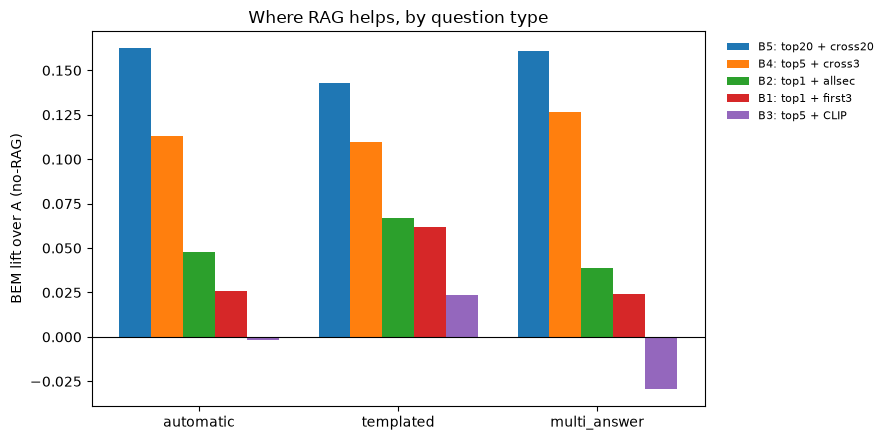

In [5]:
# Lift over the no-RAG floor (A), per question type — where does RAG actually help?
# Legend placed OUTSIDE the axes so it never covers the bars (many variants).
types = ['automatic', 'templated', 'multi_answer']
base = next((byt for l, _, _, byt in rows if l.startswith('A')), {})
variants = sorted([r for r in rows if not r[0].startswith('A')], key=lambda r: r[2], reverse=True)
x = range(len(types)); n = max(len(variants), 1); w = 0.8 / n
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, (label, _, _, byt) in enumerate(variants):
    off = (i - (n - 1) / 2) * w
    ax.bar([j + off for j in x], [byt.get(t, 0) - base.get(t, 0) for t in types], w, label=label)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(list(x)); ax.set_xticklabels(types)
ax.set_ylabel('BEM lift over A (no-RAG)'); ax.set_title('Where RAG helps, by question type')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8, frameon=False)
fig.tight_layout(); plt.show()

## Retrieval is the bottleneck
Split examples by whether the correct article is among the retrieved candidates, then measure answer accuracy on each subset (exact-match proxy, a floor of BEM; the hit-vs-miss gap is the signal).

file: predictions_cross_topK20_rerankN20.jsonl
recall (article retrieved): 12.9%
accuracy | HIT : 0.155 (n=129)
accuracy | MISS: 0.065 (n=871)


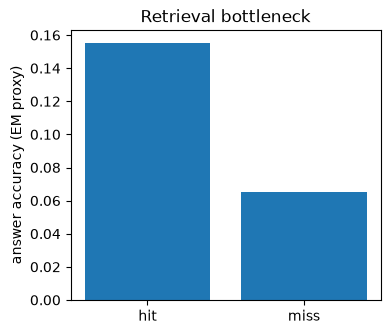

In [6]:
PUNCT = set(string.punctuation + '‘’´`_')
def _pre(a):
    a = a.lower().replace('\n', ' ').replace('\t', ' ').strip()
    a = ''.join('' if c in PUNCT else c for c in a)
    a = re.sub(r'\b(the answer is|a|an|the)\b', ' ', a)
    return ' '.join(a.split())
def correct(rec):
    if rec.get('prediction') is None:
        return False
    ref = str(rec['answer'])
    if rec['question_type'] == 'multi_answer':
        R = [x for x in (_pre(a) for a in ref.split('|')[0].split('&&')) if x]
        C = [x for x in (_pre(a) for a in rec['prediction'].replace(' and ', ',').replace(' & ', ',').split(',')) if x]
        u = len(set(R) | set(C)); return len(set(R) & set(C)) / u >= 0.5 if u else False
    return _pre(ref) == _pre(rec['prediction'])
def norm(u):
    if not u:
        return u
    u = re.sub(r'^https?://', '', u.strip().lower())
    return u.replace('en.m.wikipedia.org', 'en.wikipedia.org').rstrip('/')
def cands(p):
    rc = p.get('retrieved_context') or {}
    cs = [c['wiki_url'] for c in rc.get('candidates', [])] or ([rc['wiki_url']] if rc.get('wiki_url') else [])
    return [norm(u) for u in cs]

gt = {x['unique_id']: norm(x.get('wikipedia_url')) for x in json.load(open(BASE + '/encyclopedic_test_subset.json'))}

# best variant available (definitive full-test run)
pred_file = OUT + '/final_test/predictions_cross_topK20_rerankN20.jsonl'
if not os.path.exists(pred_file):
    pred_file = OUT + '/baselines/predictions_B5.jsonl'
preds = [json.loads(l) for l in open(pred_file) if l.strip()]
hit = [p for p in preds if gt.get(p['unique_id']) in cands(p)]
miss = [p for p in preds if gt.get(p['unique_id']) not in cands(p)]
acc = lambda s: sum(correct(p) for p in s) / len(s) if s else 0
print('file:', os.path.basename(pred_file))
print('recall (article retrieved): %.1f%%' % (100 * len(hit) / len(preds)))
print('accuracy | HIT : %.3f (n=%d)' % (acc(hit), len(hit)))
print('accuracy | MISS: %.3f (n=%d)' % (acc(miss), len(miss)))
plt.figure(figsize=(4, 3.5)); plt.bar(['hit', 'miss'], [acc(hit), acc(miss)])
plt.ylabel('answer accuracy (EM proxy)'); plt.title('Retrieval bottleneck'); plt.show()

## top-k and top-n must be scaled together
Recall rises with k; `n≈20` is the sweet spot (n=5 discards the answer paragraph, large n dilutes it). `acc_hit` is backed out from `overall = recall*acc_hit + (1-recall)*acc_miss` with `acc_miss = A`.

On the full test set the plateau is flat: at n=20, top-k 10–50 all land ~0.39–0.40, with **top-20/n20 = 0.401** the robust best (the small-val max, top-10/n30, does not transfer). The table below shows recall climbing with k while `acc_hit` stays roughly stable — confirming retrieval recall, not the reranker, is the lever.

In [7]:
dump_path = OUT + '/retrieval/retrieval_topk50.jsonl'
if os.path.exists(dump_path):
    dump = [json.loads(l) for l in open(dump_path) if l.strip()]
    def recall_at(k):
        h = 0
        for r in dump:
            g = norm(r['wikipedia_url'])
            if g and g in [norm(c['wiki_url']) for c in r['candidates'][:k]]:
                h += 1
        return h / len(dump)
    acc_miss = json.load(open(OUT + '/baselines/results_A.json'))['accuracy_overall']
    # full-test runs at fixed n=20: recall rises with k, acc_hit stays ~stable
    combos = [(5, 20), (10, 20), (20, 20), (50, 20)]
    print('%-14s %-8s %-9s %s' % ('k / top-n', 'recall', 'overall', 'acc_hit'))
    for k, n in combos:
        f = OUT + '/final_test/results_BEM_cross_topK%d_rerankN%d.json' % (k, n)
        if os.path.exists(f):
            rec = recall_at(k); ov = json.load(open(f))['accuracy_overall']
            print('top%-3d n=%-6d %-8.1f %-9.3f %.3f' % (k, n, 100 * rec, ov, (ov - (1 - rec) * acc_miss) / rec))
else:
    print('run scripts/run_recall.sh to populate the recall dump')

k / top-n      recall   overall   acc_hit
top5   n=20     27.8     0.371     0.698
top10  n=20     34.4     0.397     0.687
top20  n=20     40.6     0.401     0.629
top50  n=20     46.7     0.391     0.558


## top-20 vs top-50 (at n=20) — the final pick

The two front-runners score almost the same overall, but the choice is not a tie. On the full-test sweep **top-20/n20 (0.401) edges out top-50/n20 (0.391)** and is **better balanced across question types**: it wins on `overall`, `automatic` and `templated`, and only gives up `multi_answer` (where the wider top-50 pool adds a bit of coverage). top-20 also needs a smaller pool to rerank, so it is cheaper. That combination — a small overall gain, higher `templated`, and lower cost — is why **top-20/n20 is the chosen B5** (reported at 0.403 on the full unfiltered KB).

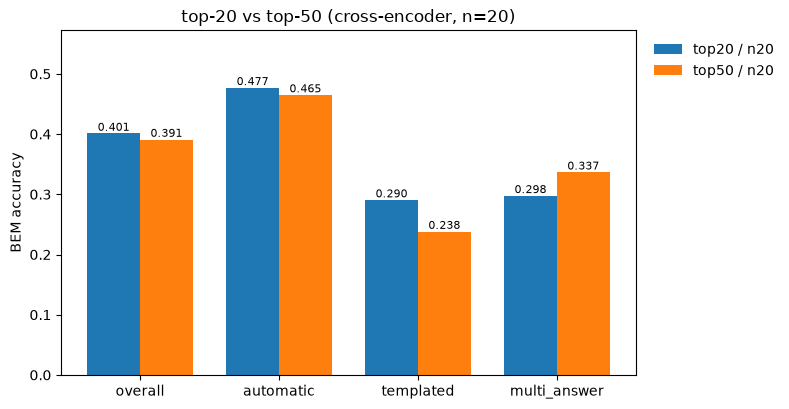

metric        top20/n20   top50/n20   Δ(20−50)
overall       0.401       0.391       +0.010
automatic     0.477       0.465       +0.012
templated     0.290       0.238       +0.052
multi_answer  0.298       0.337       -0.039


In [8]:
# top-20/n20 vs top-50/n20 (full-test sweep, outputs/final_test/) — the two front-runners
cfgs = [('top20 / n20', 'topK20_rerankN20'), ('top50 / n20', 'topK50_rerankN20')]
metrics = ['overall', 'automatic', 'templated', 'multi_answer']

def _load(tag):
    d = json.load(open(OUT + '/final_test/results_BEM_cross_%s.json' % tag))
    return [d['accuracy_overall']] + [d['accuracy_by_type'].get(m, 0) for m in metrics[1:]]

vals = {name: _load(tag) for name, tag in cfgs}
x = range(len(metrics)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.2))
for i, (name, v) in enumerate(vals.items()):
    off = (i - 0.5) * w
    bars = ax.bar([j + off for j in x], v, w, label=name)
    for b, val in zip(bars, v):
        ax.text(b.get_x() + b.get_width() / 2, val, '%.3f' % val, ha='center', va='bottom', fontsize=8)
ax.set_xticks(list(x)); ax.set_xticklabels(metrics)
ax.set_ylabel('BEM accuracy'); ax.set_ylim(0, max(max(v) for v in vals.values()) * 1.2)
ax.set_title('top-20 vs top-50 (cross-encoder, n=20)')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False)
fig.tight_layout(); plt.show()

d20, d50 = vals['top20 / n20'], vals['top50 / n20']
print('%-13s %-11s %-11s %s' % ('metric', 'top20/n20', 'top50/n20', 'Δ(20−50)'))
for m, a, b in zip(metrics, d20, d50):
    print('%-13s %-11.3f %-11.3f %+.3f' % (m, a, b, a - b))

## Observations

| Variant | What it tests | Verdict |
|---|---|---|
| A | no retrieval (floor) | reference 0.245 |
| B1 top1 + first3 | cheapest RAG | small gain over A |
| B2 top1 + allsec | more context, 1 article | all sections > first 3 |
| B2.1 top5 + allsec | more candidate articles | more candidates help (0.347) |
| B3 top5 + CLIP | question-aware rerank (CLIP) | **hurts** — discards good paragraphs |
| B4 top5 + cross3 | cross-encoder rerank | good reranker ≈ give-all (0.360) |
| B4.1 top5 + cross15 | more paragraphs @ top-5 | no gain — top-n second-order at low top-k |
| B5 top20/top50 + cross5 | higher recall | recall up (28→47%) but reranker dilutes |
| B5 top20 + cross20 | high recall + top-n 20 | **best (0.403)** — full test, top-k and top-n scaled together |

**What works:** cross-encoder rerank (never CLIP); scaling top-k *and* top-n together; a generous reranked set (Qwen is robust to noise).

**What doesn't:** CLIP rerank (worse than none); raising top-k alone with a small top-n; more paragraphs at low top-k.

**Bottleneck:** retrieval recall (see `../03_recall_curve`). When the right article is found the VLM answers ~66%; it isn't found ~53–72% of the time.

**KB context (tested, kept full):** we tried excluding service/short paragraphs (References, See also, External links, stubs — ~30% of pooled text) from the context. BEM was unchanged (0.401 filtered ≈ 0.403 full, within noise), so the exclusion is **not** applied: keeping every paragraph costs nothing here and preserves the references/links the agent (C) may want to follow. Headline B uses the full, unfiltered KB.

**Prompt-style sweep (tested, dropped):** a system-prompt sweep (strict / fallback / reasoning / combined) and a ReAG-style context prompt moved accuracy little or *hurt* (a short-answer/entity-biased prompt collapsed to ~0.21 zero-shot). Prompting is not a useful lever for B — the gain is in retrieval.

**Next:** agentic RAG (C), targeting retrieval recall (the ~53% of misses).